In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math


import mesa
from mesa.datacollection import DataCollector
from mesa import Model,Agent
from mesa.space import MultiGrid
from mesa.experimental.cell_space import CellAgent, FixedAgent, OrthogonalVonNeumannGrid
from mesa.experimental.devs import ABMSimulator
from mesa.visualization import Slider, SolaraViz, make_plot_component, make_space_component
#.model for all times you want to look at all the grid at a time point, .grid for all grid fucntions and no 

In [445]:
#This cell is used for the base class of bronchial
class Bronchial(CellAgent):
    def __init__(self, model, pos, health, init_health =100,): 
        super().__init__(model)
        self.init_health = init_health #initial health of bronchial
        self.health = health
        self.pos = pos
        #should we create a layer of underlaying cells that can be invaded
        #we are starting with higher mucin levels due to the types of conditions we are modeling 
    
        
    #Healing mechanism after injury state
    def healing(self):
        bronch_space = self.model.grid.get_neighbors(self.pos, moore= False)
        for obj in bronch_space:
            if isinstance(obj,Pathogen):
                continue
            elif self.health<self.init_health:
                self.health +=5
                break
    

    #Replenishment mechanism after death state
    def replacement(self):
        for i in range(len(self.model.death_step_list)):
            death_count=(self.model.step_count - self.model.death_step_list[i])
            if death_count>=21:
                deadpos = self.model.death_pos_list[i] #this way cells that are newly generated can fill in the the middle the same cell should be remade because theyre popped from the list
                #if the nieghboring cell has been dead for the full timepoint, assumption a full replacement cycle is 20hrs and it appear on the 21st hour, you dont count the first step because that step is where the death was happening, the next step is where the replacement can start to occur
                allpathogendeathpos =[obj for obj in self.model.grid.get_cell_list_contents(deadpos) if isinstance(obj,Pathogen)]
                if (deadpos[0]==(self.pos[0]+1) or deadpos[0]==(self.pos[0]-1)) and len(allpathogendeathpos)==0:
                    health=100
                    repbronch = Bronchial(self.model,deadpos,health,self.init_health,)
                    self.model.grid.place_agent(repbronch,deadpos)
                    self.model.death_step_list.pop(i)
                    self.model.death_pos_list.pop(i)
                    break
                elif len(allpathogendeathpos)>0: #assume the only thing that can be in that cell is a pathogen and itll push back healing by two and it can't heal with its there i think?
                    self.model.death_step_list[i]+=2 
                #should we check if its bronchiol or pathogen if the upper part eliminating it from the list once its replaced should prevent other nieghbor from replacing it 
                 

    #In infected state, macrophages get called as body's self defense system
    def call_macro(self):
    #Limit macrophage in the environment to 100 and in the bloodstream to 5
        tot_macro = 0 #total macrophages in grid
        tot_blood_macro = 0 #total macrophages in bloodstream
        for x in range(self.model.grid.width):
            for y in range(self.model.grid.height):
                pos = x,y
                grid_macro = self.model.grid.get_cell_list_contents(pos)
                for m in grid_macro:
                    if isinstance(m, Macrophage):
                        tot_macro += 1
            for y in range(2):
                pos = x,y
                blood_macro = self.model.grid.get_cell_list_contents(pos)
                for m in blood_macro:   
                    if isinstance(m, Macrophage):
                        tot_blood_macro += 1 
        while tot_macro < 100 and tot_blood_macro < 5: #Call macrophages into bloodstream 
            x = self.random.randrange(self.model.grid.width)
            y = self.random.randrange(2)
            pos = (x,y)
            self.model.call_macro(pos)
            tot_macro += 1
            tot_blood_macro += 1

    # #First, it checks how many macrophages are in the bloodstream, limit it to 5
    #     tot_macro = 0 # how many macrophages are in there 
    #     for x in range(self.model.grid.width):
    #         for y in range(2):
    #             pos = x,y
    #             blood_macro = self.model.grid.get_cell_list_contents(pos)
    #             for m in blood_macro:
    #                 if isinstance(m, Macrophage):
    #                     tot_macro += 1
    #     while tot_macro < 6: #ensures no more than 5 macrophages enter the body
    #         x = self.random.randrange(self.model.grid.width)
    #         y = self.random.randrange(2)
    #         pos = (x,y)
    #         self.model.call_macro(pos)
    #         tot_macro +=1

    #Secretion of mucin in infected state, health of bronchial impacts amount secreted
    def call_mucin(self): 
        infect_int = 1 
        if self.health <= 25:
            infect_int = 3
        elif self.health <=50:
            infect_int =  2
        pos=(self.pos[0],self.pos[1]+1)
        for i in range(infect_int):
            self.model.call_mucin(pos)


    #idk if we wanna put it here or with the pathogen but this code can be used to make it lose a certain amout of health based on whats stuck to it?
    #i think both work cuz once we refer to the other it will call it and we can do like pathogen.energy or bronchial.health
    
    #Injury of Bronchiol done by pathogens
    def health_loss(self):
        bronch_space = self.model.grid.get_neighbors(self.pos, moore=False)
        bact_no = 0
        bact_no += sum(obj.strength for obj in bronch_space if isinstance(obj, Pathogen) == True)
        #bact_no += sum(obj.strength*0.25 for obj in bronch_space if isinstance(obj, Pathogen) == True and (not obj.pos[0]==self.pos[0])) #only if the pathogen is right on top of it and other nieghbors have half the effect 
        #idk should we increase the radius?
        #i think y lowkey forgot to actually decrease the health, so im gonna add it 
        self.health= max(0, self.health - bact_no)
        
    #what happens each step
  
    def step(self):
        self.healing()
        if self.model.step_count>0:
            self.health_loss()
        
        if self.health < 75 and self.model.step_count%2==0 and (self.health!=0): #Health determines how much mucin is called, macrophages are predetermined
            self.call_macro()
            self.call_mucin()
    
        if self.health <= 0:
            self.model.death_step_list.append(self.model.step_count)
            self.model.death_pos_list.append(self.pos)
        if self.health <= 0:
            self.model.grid.remove_agent(self)
            self.remove()
            return
        self.replacement()
        self.model.death_tracker()


In [446]:
#This cell is used for the base class of the bacteria and biofilm formation
class Pathogen(CellAgent):
    def __init__(self, model, pos, health = 100, energy=100, strength = .5, bacteria_gain= 10, p_rep = 0.04, biofilm_form = False, p_unstick = 0.04, alive = True):
        super().__init__(model)
        self.pos = pos
        self.health = health #Lifespan of pathogen
        self.strength = strength #how much damage it deals to brocnhial
        self.bacteria_gain = bacteria_gain #how much "health" bacteria gains from bronchiol damage, did we even use this lowkey cause like they dont really gain from being 
        self.p_rep = p_rep #probability to trigger reproduction
        self.p_unstick = p_unstick #probability of bacteria in biofilm to "unstick" from biofilm
        self.energy=energy
        self.biofilm_form = biofilm_form
        self.alive = alive

    #Movement of pathogen is limited by mucus, and evasive of macrophages. Otherwise it is random
    def move_bacteria(self):
        #macrophage will move within mucin
        findneighbors = self.model.grid.get_neighbors(self.pos,True,False)
        macro_free_list=[] #List of positions safe of macorphage
        distances=[] #List of possible mucin positions
#energy is increased when the bronchiales and gains every couple ticks and assumption of correct acmount nutrients, and divide loses energy and cant divide after a certian point. Health for the antibiotics, limitations parameter of how the bacteria heals or adapts to the antibiotic, but other than that once health is lost is isnt regain. 
#energy only gained during first attachtment, if we can add protional increases per step, if not ut in future directions, either losing energy when in conatact with antibiotic or a limit on the health you need for duplication or decrease the chances.
#until 25 percent health it can keep rep just not as high probabilty 
#
        for agent in findneighbors:
            if isinstance(agent,Mucin):
                distances.append(agent.pos[1])
                maxmucin=max(distances)
            else:
                maxmucin=self.pos[1]  
        if self.pos[1]>2 and (self.pos[1])<=maxmucin: #this may have to be fixed
            for obj in findneighbors:
                if not isinstance(obj,Macrophage):
                    macro_free_found = obj.pos
                    macro_free_list.append(macro_free_found)
            for cells in findneighbors:
                if isinstance(cells,Bronchial): #Check for bronchial neighbors to stick on to 
                    bac_space = self.model.grid.get_cell_list_contents([self.pos])
                    #bac_no = 0
                    #x,y = self.pos
                    bac_no = sum(1 for obj in bac_space if isinstance(obj, Pathogen) == True)
                    if bac_no >10 or self.random.random() < 0.2: #Chance of pathogen detaching from Bronchiol and moving
                        #possible_directions = [(x,y), (x+1,y), (x-1, y), (x+1, y+1), (x-1, y+1), (x,y+1)]
                        # bac_spread = self.random.choice(possible_directions) #wait what the freak they should still only move to places with macro
                        # self.model.grid.move_agent(self, bac_spread)
                        self.model.grid.move_agent_to_one_of(self,macro_free_list)
                    else:
                        return
            if len(macro_free_list)>0:
                self.model.grid.move_agent_to_one_of(self,macro_free_list)
            else:
                return
        else:
            return
    #damaging the bronchiol - cell loses healt, brionchial gains health

    #Movement of pathogens affected by cilia
    def move_cilia(self):
        self.model.grid.move_agent(self, (self.pos[0]-1,self.pos[1]))
        #if biofilm is formed then we gotta lowkey limit the movement ig


    #Biofilm formation upon contact with other pathogens
    def biofilm_formation(self): # i lowkey dont think any oft his is right ehe
        return
    # #bacteria gain only here when in bioform gets to full in less time or something like that 
    #     #idea before implementation - model biofilm by just makeing them stick to each other and then increasing the health by a certain ffactor when x amount is present and maybe
    #     #we can also model it to have a certain step strength in a random direction that will decrease the more are connected? and we can have antibiotic deal damage exactly as large as the health or say it insta kills it vs deald this mich dMG when not insta kill
    #     #model prob of unstick with liek if random is (p sunstick then it will detach)

    #     #mucin within a one distance radius will begin to stick together   
    #     bac_test = self.model.grid.get_neighbors(self.pos, True, True)
        
    #     for agent in bac_test:
    #         #if agent isinstanc(agent, Pathogen):
    #         return  

    #     #code to model bacteria stikcing together in biofilm
    #     if bacteria.present.available and (self.biof_formed == False):
    #         #insert code here lol
    #         self.biof_formed = True

    #     #probability of bacteria to stop sticking to biofilm
    #     if (self.biof_formed== True) and (self.random.random() < self.p_unstick):
    #         #insert code here lol
    #         self.biof_formed = False



    #Reproduction rate of pathogen
    def spawn_offspring(self):
        #using half of its health, it can spawn offspring
        self.energy /= 2
        new_bac= Pathogen(self.model, self.pos,self.health,self.energy, self.strength, self.bacteria_gain, self.p_rep)
        self.model.grid.place_agent(new_bac, self.pos)



#need to manipulate macrophage and pathogen so energy function is like lab 6

    #What happens each step
    def step(self):
        # if self.alive == False:
        #     self.remove()
        #     return
        bac_space = self.model.grid.get_cell_list_contents([self.pos])
        bac_no = sum(1 for obj in bac_space if isinstance(obj, Pathogen) == True)
        if  bac_no<3 and (self.pos[0] ==0): #Cilia push pathogens out as a primary line of defense
            self.remove()
            return
        elif bac_no<3: 
            self.move_cilia() #Assumption of cilia only pushing pathogens out (not in ) 
        self.move_bacteria() #Movement, does not move when touching Bronchial 
        #code for bacteria touching the 


        # #self.biofilm_formation()
        self.energy-=5
            # self.alive = False
        if self.random.random() < self.p_rep :
            self.spawn_offspring()
        if self.model.step_count%3==1:
            if self.energy!=20:                       
                self.energy=20
        if self.energy<=0:
            self.remove()
        
            #this is the assumption that every 3 steps all there are enough nutrients that bacteria regain 25% of there lost energy 



In [447]:
#This cell is used for the base class of the mucin, which are particles of mucus
class Mucin(CellAgent):
    def __init__(self, model, pos):
        super().__init__(model)
        self.pos = pos
        #viscosity as parameter to multiple stuff by? or we set it as a probablity and timestep of killing rando, mucus
    #mucus acts as a medium for the antibiotics, pathogens, and macrophages to travel

    #Movement of mucus through cilia
    def move_cilia(self):
            for i in range(12): # moves cilia right 12 times * we might need to move this part to step
                self.model.grid.move_agent(self, (self.pos[0]-1,self.pos[1])) # multiply that moevemt later when u can based on healtj
        #inflammation (bronchiol health dec) will decrease movement 
    
    #Clearance of mucus through prodcuctive cough
    def move_cough(self):
        #define how much "agents" get moved in one cough, needs same clearance boundaries as move cilia
        # i dont think this is enough for the cough i think it needs to be repeated?
        self.model.grid.move_agent(self, (self.pos[0]-2, self.pos[1]))

    #Generation of more mucin pushed by cilia into grid
    def ciliaspaw(self): # move when it spawns
        y=self.random.choice([3,4])
        pos=(19,y)
        self.model.gen_cilia(pos)

    #Spread of mucin limited by the number of mucins in each grid spot 
    def mucin_spread(self): 
        #Count total mucin in one grid spot
        muc_space = self.model.grid.get_cell_list_contents([self.pos])
        muc_no = 0
        muc_no = sum(1 for obj in muc_space if isinstance(obj, Mucin) == True)
        
        #Movement if limit of mucin is reached
        if muc_no > 5:
            muc_surround = self.model.grid.get_neighborhood(self.pos, moore = True)
            if self.pos[1] == 3: #If above Bronchial, it cannot move down
                x = self.pos[0]
                y = self.pos[1]
                possible_directions = [(x,y), (x+1,y), (x-1, y), (x+1, y+1), (x-1, y+1), (x,y+1)]
                muc_spread_pos = self.random.choice(possible_directions)
                self.model.grid.move_agent(self, muc_spread_pos)
            else: #Can go any direction
                muc_spread_pos = self.random.choice(muc_surround)
                self.model.grid.move_agent(self, muc_spread_pos)
            
            #If the "mucin went too far" if it dd it will "fall"
            muc_test = self.model.grid.get_neighbors(self.pos, moore = True, radius= 2)
            if (len(muc_test) < 10) and (self.pos[1] != 3):
                self.model.grid.move_agent(self, (self.pos[0], self.pos[1]-1 ))
                #this works but it seems to be causing lag, everything else i did didnt


            #self.model.grid.move_agent(self, (self.pos[0]-2, self.pos[1]))
            
            #self.viscosity = 0.2
            #use this value to spread mucin properly + use to decide viscosity 
                #if muc> 5 : viscosity = 1 , 0.5, 0.4 - > multiply dorectly into movement
                

    #What happens each step
    def step(self):
        self.mucin_spread() #- im thinking add it at the end instead of the start (lol nvm its all those retrins wont lalow it)
        # lol rn its spwning like 100000 and causing rlly slow runtime - current fix is return all func 
        bronch_health_check = list(self.model.agents_by_type[Bronchial])
        for b in bronch_health_check: #change this so that it will trigger if any of them 
            #idk if this will wokr but im thinking of running each b in an if statement then add it to a new variable, then use those that variable 
            #next question is if we want a certain no of injured ones to trigger it multiple times or no
            if b.health > 75: # healthy state of body. temporary health value
                if  (self.pos[0] ==0): 
                    self.remove()
                    self.ciliaspaw()
                    return
                else:
                    self.move_cilia()
                    return
            elif b.health < 75: #Infected state of body causes cough
                if self.model.step_count > 5: #only in infected state
                    if self.model.random.random() < 0.5:
                        if  (self.pos[0] == 1 or self.pos[0] == 0):
                            self.remove()
                            return
                        else:
                            self.move_cough()
                            #make cough work more if there is less viscosity or more empty cells between mucin
                            return
        #self.mucin_spread()
                        

       



In [448]:
#this cell is used for the base class of the macrophage
class Macrophage(CellAgent):
    def __init__(self, model, pos, energy = 8, strength = 5, macrophage_gain= 4, p_rep = 0.04):
        super().__init__(model)
        self.pos = pos
        self.energy = energy
        self.strength = strength
        self.macrophage_gain = macrophage_gain
        self.p_rep = p_rep
#set the max and set the removal mechanism
    #movement - aims for the bacteria
    #addd the max amount to call and here and look up the replication rates for macro and pathogens
    #set up graphs for the health and the opacity, tells you how many of each health there is in atime point.
    #set up the ajustable parameters 
    #remove helath and strengh and set up either here or in pathogen to remove them when eaten
    
    #Movement of macrophage within mucin
    def move_macrophage(self):
        findneighbors = self.model.grid.get_neighbors(self.pos,True,False)
        pathogen_found_list=[]
        distances=[]
        for agent in findneighbors:
            if isinstance(agent,Mucin):
                distances.append(agent.pos[1])
                maxmucin=max(distances)
            else:
                maxmucin=self.pos[1]
        #
        if self.pos[1]>2 and self.pos[1]<=maxmucin: #I dont want them to leave the mucin but they in theory shouldnt as long at there is bacteria near by we could limit them to the tallest mucin with get all cells find the farthest distance with get distance and based on that put an if condition, but we can see
            for obj in findneighbors:
                if isinstance(obj, Pathogen):
                    pathogen_found=obj.pos
                    pathogen_found_list.append(pathogen_found)
        #do we want random movement? if yes, i think this needs to go in a diff if, else line
            if len(pathogen_found_list)>0:
                self.model.grid.move_agent_to_one_of(self,pathogen_found_list)
            else:
                return
        elif self.pos[1]<=2:
                self.model.grid.move_agent(self,(self.pos[0],self.pos[1]+1)) 
                #for now its in step 0 but since they will only be called during infection that shouldnt be a problem
        else:
            return

    #Attack mechanism of macrophage  
    def macro_feed(self):#due to immunocompirmised state, macrphages cannot killl, only samage
        slot_space = self.model.grid.get_cell_list_contents([self.pos])
        bac = [obj for obj in slot_space if isinstance(obj, Pathogen)]
        if len(bac) == 1:
            bac_attk = self.random.choice(bac)
            bac_attk.health-=100
            self.energy+=self.macrophage_gain
            if bac_attk.health<=0:
                bac_attk.remove()
        elif len(bac) > 1:#this is only for when we actually get the bioflim to work
            bac_attk = self.random.choice(bac)
            bac_attk.health -=100
            self.energy += self.macrophage_gain
            if bac_attk.health<=0:
                bac_attk.remove()
        
        #     self.energy +=5 we need to make bioflim step based because they could just be randomly attach to each other and not in bioflim, maybe randomly they stay nieghbors for a certain amount of steps then they form they bioflim through sensing, idk, or if we are only making the bioflims attached to brochioles only make this be the case if the nieghbors of the bcteria in question are brnchiolo

    def spawn_rep(self): #mechanism for macrophages to increase through replication
        #using half of its health, it can spawn offspring
        self.energy /= 2
        new_macro= Macrophage(self.model, self.pos,self.energy, self.strength, self.macrophage_gain_gain, self.p_rep)
        self.model.grid.place_agent(new_macro, self.pos)
    
    def move_cilia(self):
        self.model.grid.move_agent(self, (self.pos[0]-1,self.pos[1]))
 
#in the future only eat a precentage of the time, model them being immune comprimesd by macropheges not always working and less max amount then in the Lab 6 for not going into immmune overload.
#rn its based on percentage of time and based on biofilm health

    #what happens each step
    def step(self):
        if  (self.pos[0] ==0): 
            self.remove() #assumption theyre only moving out but not in for now 
        else:
            self.move_cilia() 
        self.move_macrophage()
        self.energy-=5
        if self.model.random.random() < 0.5: #only in bioflim
            self.macro_feed()
            return
        #doesnt move if there is no macrophage once its out of the capillary 
        #will moving and cntact decrease health?

In [449]:
#this cell is used for the base class of antibiotics
class Antibiotic(CellAgent):
    def __init__(self, model,pos, health = 15, strength = 10,alive = True):
        super().__init__(model)
        self.pos = pos
        self.health = health
        self.strength = strength
        self.alive = alive

    #Antibiotic production(idt this is theright word lol)
    def call_anti(self):  #idk if we wanna adjustable concentration we probabaly need to make this an attritube and set it to call a certain amt (like call_macro)
        #for i in range(5):
            x = self.random.randrange(self.model.grid.width)
            y = self.random.choice([0,1])
            pos = x,y
            new_anti= Antibiotic(self.model, pos,self.health, self.strength)
            self.model.grid.place_agent(new_anti, pos)


    #Movement of antibiotics limited by mucin intensity
    def move_anti(self): #as far as im concerned this shoudl be working good
        #limiting the movement of the antibiotics based on mucin content, epithelial layer and biofilm formation
        anti_move_c = self.model.grid.get_neighbors(self.pos, True, radius = 1)
        muc_limit = [] #list to set the limit antibiotic movement to mucin
        muc_limit_layer = 0
        anti_found = False 
        anti_spread = [] #Better spread (diffusion) of antibiotics by having them "evade" each other
        
        for agent in anti_move_c:
            if isinstance(agent, Mucin):
                muc_limit.append(agent.pos[1])
            if isinstance(agent, Antibiotic) == False:
                anti_found = True
                anti_spread.append(agent.pos)
        if len(muc_limit) > 0:
            muc_limit_layer = max(muc_limit)

        
        slot_space = self.model.grid.get_cell_list_contents([self.pos])
        muc_no = 0
        limit_move = 1
        biofilm = False
        muc_no = sum(1 for obj in slot_space if isinstance(obj, Mucin) == True)
        bac_no = sum(1 for obj in slot_space if isinstance(obj, Pathogen) == True)
        # if muc_no >= 5:
        #     limit_move = 0.5
        # elif muc_no >=3:
        #     limit_move = 0.75
        move_mag = 1*limit_move #right now limiting movement to float values will break pos, i think instead we need flat values
        if bac_no > 3:
            biofilm = True
        x,y = self.pos

        #Movemment of antibiotics
        if self.pos[1] < 3: #Initial diffusion from bloodstream
            self.model.grid.move_agent(self, (self.pos[0], self.pos[1]+1 )) 
        elif biofilm ==True: # stops movement of the antibiotic to stick on biofilm
            pass
        elif self.pos[1] ==3 : #Ensure it does not go back down
            possible_directions = [(x,y), (x+move_mag,y), (x-move_mag, y), (x+move_mag, y+move_mag), (x-move_mag, y+move_mag), (x,y+move_mag)]
            anti_pos = self.random.choice(possible_directions)
            self.model.grid.move_agent(self, anti_pos)
        elif self.pos[1] >=muc_limit_layer: #Limitied by max layer mucin
            possible_directions = [(x,y), (x+move_mag,y), (x-move_mag, y), (x+move_mag, y-move_mag), (x-move_mag, y-move_mag), (x,y-move_mag)]
            anti_pos = self.random.choice(possible_directions)
            self.model.grid.move_agent(self, anti_pos)
        elif anti_found == True: # Ensure antibiotics are not overlapping with one another (diffusing properly)
            anti_move = self.random.choice(anti_spread) 
            move_x = anti_move[0] - x
            move_y = anti_move[1] - y
            anti_pos = (x + (move_x * move_mag), y + (move_y * move_mag))
            self.model.grid.move_agent(self, anti_pos)
        else: #other options = movement not limited
            anti_move = self.random.choice(anti_move_c)
            move_x = anti_move[0] - x
            move_y = anti_move[1] - y
            anti_pos = (x + (move_x * move_mag), y + (move_y * move_mag))
            self.model.grid.move_agent(self, anti_pos)
        #im not sure if i want this to be sepearet or an elif command written in but for now im combingin it 
        #ensures that the antibiotics are 

    
    def kill_bacteria(self):
        slot_space = self.model.grid.get_cell_list_contents([self.pos])
        bac = [obj for obj in slot_space if isinstance(obj, Pathogen)]
        if len(bac) == 2: 
            bac_atk=self.random.choice(bac)#If bacteria has not formed biofilm, it will kill one pathogen in and get destroyed
            bac_atk.alive = False
            self.alive = False
            if bac_atk.alive == False:
                bac_atk.remove()
        elif len(bac) > 3: #formation of biofilm will decrease effectiveness and will keep it stuck on it and decrease health
            bac_atk = self.random.choice(bac)
            bac_atk.health -= 50
            self.health -=5
            if bac_atk.health<=0:
                bac_atk.remove()
        elif len(bac) > 5: #formation of stronger biofilm will decrease further
            bac_atk = self.random.choice(bac)
            bac_atk.health -= 25
            self.health -=5
            if bac_atk.health<=0:
                bac_atk.remove()


            #the antibiotic slowly dealing damage to the bacteria not immediate and the bacteria can keep functioning while being attack (find paper) and then eventually randomize and sometimes they ust weaken alot
#set up that bioflim attracts mucin so that antibiotic diffuses slower, and once in the bioflim itll diffuse slowest.
#schedule event for when the cells starts attacking not immediate in biofilm
#right now it only attacks one even if theres 5, we can run a for loop to make it attack all w indexing

#when its a normal free bacteria itll destroy it and destroy itself, if it a biofilm it made just remain in the bioflim not making any until an amount of ticks and then itll deal the damage to whatever bacteria it is on top off

    def step(self):
        if getattr(self, "alive", True) is False:
            return
        if self.model.step_count%14==1:
             self.call_anti()
             
        self.move_anti()
        self.kill_bacteria()
        if self.health <= 0 or self.alive == False:
            # self.model.grid.remove_agent(self)
            self.remove()
        

In [450]:
#this cell is used for the creation of the model, which creates the grid
class LungModel(Model): 
    def __init__(self, width=20, height=20, init_health_Bronchial=100, macrophage_gain=50, seed=100, simulator=None):
        super().__init__(seed=seed)
        self.simulator = simulator
        self.simulator.setup(self)
        self.grid = MultiGrid(width, height, torus=True)
        self.step_count=0 
        self.death_step_list=[]
        self.death_pos_list=[]
        reporters = {
            "Mucin": lambda m: len(m.agents_by_type.get(Mucin,[])),
            "Bronchial": lambda m: len(m.agents_by_type.get(Bronchial,[])),
            "Pathogen": lambda m: len(m.agents_by_type.get(Pathogen,[])),
            "Antibiotic": lambda m: len(m.agents_by_type.get(Antibiotic,[])),
            "Macrophage": lambda m: len(m.agents_by_type.get(Macrophage,[]))

        }
        agent_reporters = {
            "Bronch_health": lambda b: b.health if isinstance(b, Bronchial) else None
            }
        self.datacollector = DataCollector(reporters, agent_reporters)


        #Set the fixed position of the bronchial layer
        for x in range(width):
            epithelial=Bronchial(
                self,
                (x,2),health=init_health_Bronchial,
                init_health = init_health_Bronchial,
                ) #Makes 20 of the bronchial, the ali form makes batches of randomly placed
            self.grid.place_agent(epithelial, (x,2))

        #Initial mucin of 1 layer, then the rest is randomized
        for x in range(width):
            y=self.random.choice([3,4])
            mucus_layer= Mucin(self,(x,y),)
            self.grid.place_agent(mucus_layer,(x,y))
        self.total_mucin = 20
        while self.total_mucin != 50:
            for y in range(3,5):
                x = self.random.randrange(self.grid.width)
                mucus_layer= Mucin(self,(x,y),)
                self.total_mucin+=1 #random placement within first line
                self.grid.place_agent(mucus_layer,(x,y))

        #Spawn pathogens within bounds of mucus
        total_bact = 0
        while total_bact != 10 :
            x = self.random.randrange(self.grid.width)
            y = self.random.randrange(self.grid.height)
            if any(isinstance(agent, Mucin) for agent in self.grid[x][y]): # might need to change this to be a range of the grid w mucin in it
                total_bact+=1
                bacteria = Pathogen(
                    self,
                    pos = (x,y),
                    health = 100, energy=self.random.random()*20,#a fifth the initial for macro
                    strength = 5, #start from layer above
                    bacteria_gain= 10,
                    p_rep = 0.04,
                    p_unstick = 0.04,
                    alive = True,
                    biofilm_form = False
                )
                self.grid.place_agent(bacteria, (x,y))
        #Ask ali if its okay to the proportions of energy that where used in Lab 6  for the energies of macrophages and bacteria 
        #Spawn macrophages within bounds of mucus
        total_macro = 0
        while total_macro != 5 : 
            x = self.random.randrange(self.grid.width)
            y = self.random.randrange(self.grid.height)
    
            if any(isinstance(agent, Mucin) for agent in self.grid[x][y]):
                total_macro+=1
                macrophages = Macrophage(
                    self,
                    pos = (x,y),
                    energy = self.random.random()*(2*macrophage_gain),
                    macrophage_gain = 50,
                    p_rep = 0.04,
                    )
                self.grid.place_agent(macrophages, (x,y))

        #Spawn antibiotics within blood vessel -> lowkey i think we do not wanna initialize any antibiotic or it will quickly kill the pathogens
        #yeah make it happen like on day 2 or 3 and only increase by a given amount every day to better model it 
    def antibiotic_first_dosage(self):
            total_anti = 0
            while total_anti != 5:
                x = self.random.randrange(self.grid.width)
                y = self.random.randrange(2)
                antibiotic=Antibiotic(
                self,
                pos=(x,y),
                health = 15,
                strength= 10,
                alive = True
                )
                self.grid.place_agent(antibiotic, (x,y))
                total_anti +=1
#figure out how to initilize antibiotics
#make a bioflim attribute that forms once bacteria are attached and nieghbors for certain time steps
#Old code for spawning antibodies 
        # for x in range(width):
        #     y = self.random.randrange(2)
        #     antibiotic = Antibiotic(
        #         self,
        #         pos = (x,y),
        #         health = 15,
        #         strength= 10,
        #         alive = True
        #         )
        #     self.grid.place_agent(antibiotic, (x,y))

        #needs to be in model because in agent it does it does every step for every agent
        #I wonder if there is a way to know the hieght of the tallest mucin like its y position
        

    #functions to call agents from other agents

    #generation of mucin based on cilia movement
    def gen_cilia(self,pos):
        #while self.mucin_gen != 12:
            y=self.random.choice([3,4])
            pos=(19,y)
                 #i wonder if there is a way to alter this depending on how much mucin hieght in the y direction 
            new_mu = Mucin(self,pos)
            self.grid.place_agent(new_mu, pos)
            #self.mucin_gen+=1

    #Calling macrophages in infected state
    def call_macro(self,pos): 
        x = self.random.randrange(self.grid.width)
        y = self.random.randrange(2)
        pos = (x,y)
        new_macro = Macrophage(self,pos,
                    energy = self.random.random()*2*50,
                    macrophage_gain = 20,
                    p_rep = 0.04,)
        self.grid.place_agent(new_macro, pos)

    #Calling mucin in infected state    
    def call_mucin(self,pos): #secretes mucin in infected state
        new_mu = Mucin(self,pos=pos)
        self.grid.place_agent(new_mu,pos=pos)

    #create an initial infection function that can keep track of how many ticks have past since a bronchiol was injured or died 
    #add to data collector checking the health of the bronchioles.
    def death_tracker(self):
        if self.health_count < 1:
            if len(list(self.agents_by_type[Bronchial]))<self.grid.width:#the health count is to insure that the same step isnt double counted for cell death in it, this is needed because removed cells delete their data 
                self.health_count+=1
            elif len(list(self.agents_by_type[Bronchial]))==20: #reset if everything has been replaced
                self.death_pos_list=[]
                self.death_step_list=[]

                
        #later tune this so there is a separate counter for each bronchiol
            
    #count function for number of bacteria in a space(biofilm)
    def biofilm_formed(self):
        bac_count = 0
        bac_surround = self.grid.get_neighborhood(self.pos, True, True)
        for i in bac_surround:
            if isinstance(i, Pathogen):
                bac_count += 1
                

# think abt bc for stopping mucus at bronchior

#set the initial position of antibiotics

    #Each step of the model
    def step(self):
        self.health_count=0
        self.agents_by_type[Mucin].shuffle_do("step")
        self.agents_by_type[Macrophage].shuffle_do("step")
        if self.step_count==7: #we can make this tunable maybe?
            self.antibiotic_first_dosage()
        if len(self.agents_by_type.get(Antibiotic,[]))>0:
            self.agents_by_type[Antibiotic].shuffle_do("step")
        self.agents_by_type[Pathogen].shuffle_do("step")
        self.agents_by_type[Bronchial].shuffle_do("step")
        self.datacollector.collect(self)
        self.step_count+=1





In [451]:
# Styling for visualization
AGENT_COLORS = {
    "Bronchial": "#FD7D7B",
    "Mucin": "green",
    "Pathogen": "blue",
    "Antibiotic": "black",
    "Macrophage": "purple"
}

#Change these parameters to experiment with the model!
MODEL_PARAMETERS = {
    "width": 20, # Grid width
    "height": 20, # Grid height
    #this is wher eu would put the parameter s(if we had any)
    "bronchial_init_health": 100, # heaalth of bironchil
    "seed": 100, # Random seed for reproducibility
}
def lung_portrayal(agent):
    if agent is None:
        return
    p = {"size": 25}
    if isinstance(agent, Mucin):
        p.update({"color": AGENT_COLORS["Mucin"], "marker": "o", "zorder": 3, "size": 45}) #zorder = positioning of whihc is the tip layer
    elif isinstance(agent, Bronchial):
        p.update({"color": AGENT_COLORS["Bronchial"], "marker": "o", "zorder": 60})
    elif isinstance(agent, Pathogen):
        p.update({"color": AGENT_COLORS["Pathogen"], "marker": "o", "zorder": 4, "size" : 25})
    elif isinstance(agent, Antibiotic):
        p.update({"color": AGENT_COLORS["Antibiotic"], "marker": "o", "zorder": 4, "size" : 25})
    elif isinstance(agent, Macrophage):
        p.update({"color": AGENT_COLORS["Macrophage"], "marker": "o", "zorder": 5, "size" : 25})

    return p

model_params = {
    "width": 20,
    "height": 20,
    "bronchial_init_health": Slider("Initial Health of Bronchiol", MODEL_PARAMETERS["bronchial_init_health"], 10, 300),
}

simulator = ABMSimulator()
model_instance = LungModel(simulator=simulator)
space_component = make_space_component(lung_portrayal, draw_grid=True)
lineplot_component = make_plot_component({
    "Bronchial": AGENT_COLORS["Bronchial"],
    "Mucin": AGENT_COLORS["Mucin"],
    "Pathogen": AGENT_COLORS["Pathogen"],
    "Antibiotic": AGENT_COLORS["Antibiotic"],
    "Macrophage": AGENT_COLORS["Macrophage"]
})

page = SolaraViz(
    model_instance,
    components=[space_component, lineplot_component],
    model_params=model_params,
    simulator=simulator,
)
page



/tmp/ipykernel_208294/834858138.py:32: UserWarning: Agent 1 is being placed with
place_agent() despite already having the position (0, 2). In most
cases, you'd want to clear the current position with remove_agent()
before placing the agent again.
  self.grid.place_agent(epithelial, (x,2))
/tmp/ipykernel_208294/834858138.py:32: UserWarning: Agent 2 is being placed with
place_agent() despite already having the position (1, 2). In most
cases, you'd want to clear the current position with remove_agent()
before placing the agent again.
  self.grid.place_agent(epithelial, (x,2))
/tmp/ipykernel_208294/834858138.py:32: UserWarning: Agent 3 is being placed with
place_agent() despite already having the position (2, 2). In most
cases, you'd want to clear the current position with remove_agent()
before placing the agent again.
  self.grid.place_agent(epithelial, (x,2))
/tmp/ipykernel_208294/834858138.py:32: UserWarning: Agent 4 is being placed with
place_agent() despite already having the position

Cannot show ipywidgets in text

Running simulation for 100 steps...


/tmp/ipykernel_208294/834858138.py:32: UserWarning: Agent 1 is being placed with
place_agent() despite already having the position (0, 2). In most
cases, you'd want to clear the current position with remove_agent()
before placing the agent again.
  self.grid.place_agent(epithelial, (x,2))
/tmp/ipykernel_208294/834858138.py:32: UserWarning: Agent 2 is being placed with
place_agent() despite already having the position (1, 2). In most
cases, you'd want to clear the current position with remove_agent()
before placing the agent again.
  self.grid.place_agent(epithelial, (x,2))
/tmp/ipykernel_208294/834858138.py:32: UserWarning: Agent 3 is being placed with
place_agent() despite already having the position (2, 2). In most
cases, you'd want to clear the current position with remove_agent()
before placing the agent again.
  self.grid.place_agent(epithelial, (x,2))
/tmp/ipykernel_208294/834858138.py:32: UserWarning: Agent 4 is being placed with
place_agent() despite already having the position

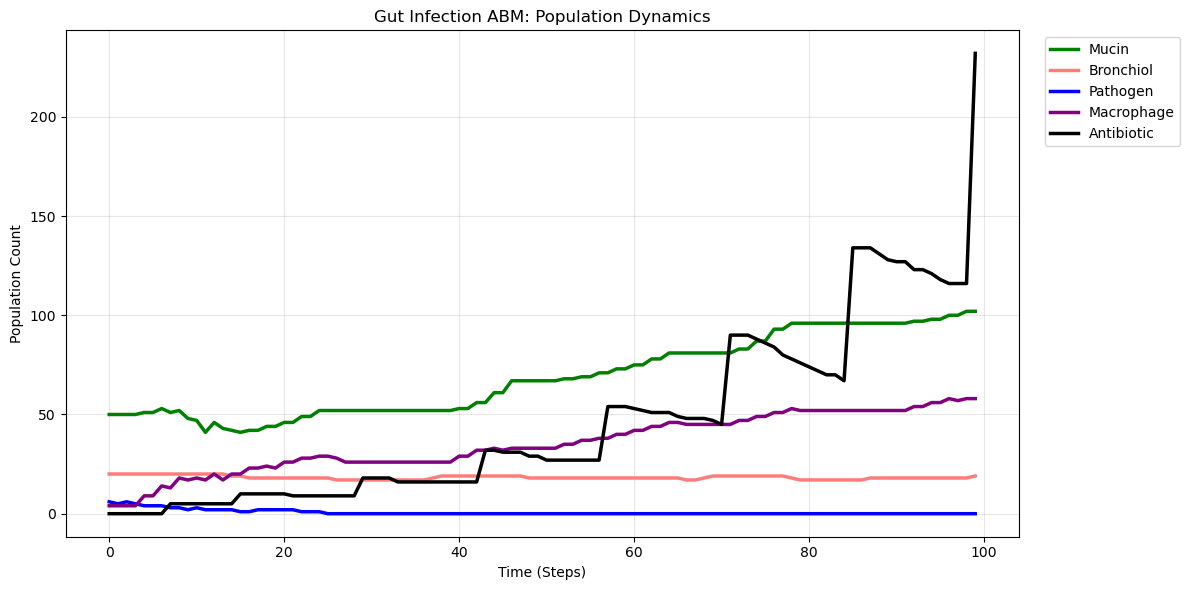

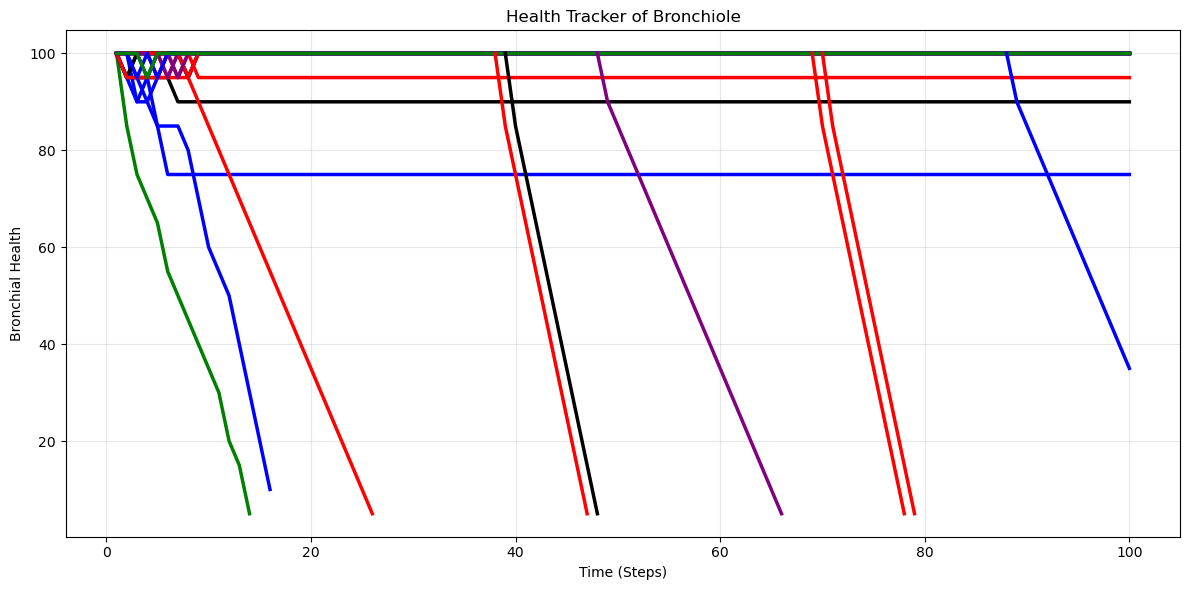

In [452]:
import matplotlib.pyplot as plt

# Change these parameters to experiment with the model!
MODEL_PARAMETERS = {
    "width": 20, # Grid width
    "height": 20, # Grid height
    #this is wher eu would put the parameter s(if we had any)
    "init_health_Bronchial": 100, # heaalth of bironchil
    "seed": 100, # Random seed for reproducibility
}

# Change this value to run the simulation for more or fewer steps
steps_to_run = 100

print(f"Running simulation for {steps_to_run} steps...")

backup_simulator = ABMSimulator()

# New model instance separate from the one used in the SolaraViz
backup_model = LungModel(
    simulator=backup_simulator,
    **MODEL_PARAMETERS
)

# for _ in range(steps_to_run):
#     backup_model.step()

backup_simulator.run_for(steps_to_run)

df = backup_model.datacollector.get_model_vars_dataframe()

plt.figure(figsize=(12, 6))

plt.plot(df.index, df["Mucin"], color=AGENT_COLORS["Mucin"], label="Mucin", linewidth=2.5)
plt.plot(df.index, df["Bronchial"], color=AGENT_COLORS["Bronchial"], label="Bronchiol", linewidth=2.5)
plt.plot(df.index, df["Pathogen"], color=AGENT_COLORS["Pathogen"], label="Pathogen", linewidth=2.5)
plt.plot(df.index, df["Macrophage"], color=AGENT_COLORS["Macrophage"], label="Macrophage", linewidth=2.5)
plt.plot(df.index, df["Antibiotic"], color=AGENT_COLORS["Antibiotic"], label="Antibiotic", linewidth=2.5)


# Formatting
plt.title("Gut Infection ABM: Population Dynamics")
plt.xlabel("Time (Steps)")
plt.ylabel("Population Count")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1)) # Puts legend outside the plot
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Display the plot
plt.show()

# TIP: To save this image for your PDF, right-click the plot and select "Save image as..."
# Alternatively, uncomment the line below to save it directly to your folder:
# plt.savefig("my_time_series.png", dpi=300)


import random
#This is a graph to observe health of bronchial over time
df_agent = backup_model.datacollector.get_agent_vars_dataframe()

random_color = ["red","purple","blue","green", "black"] # lol this is the only thing i can think of to make it easier to read for now esp if we r working with so many types 

plt.figure(figsize=(12, 6))
agents_df = df_agent.index.get_level_values("AgentID").unique()
for i in agents_df:
    health_b = df_agent.xs(i, level="AgentID")
    plt.plot(health_b.index, health_b["Bronch_health"], color=random.choice(random_color), linewidth=2.5)

# Formatting
plt.title("Health Tracker of Bronchiole")
plt.xlabel("Time (Steps)")
plt.ylabel("Bronchial Health")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

First simulation running


/tmp/ipykernel_208294/834858138.py:32: UserWarning: Agent 1 is being placed with
place_agent() despite already having the position (0, 2). In most
cases, you'd want to clear the current position with remove_agent()
before placing the agent again.
  self.grid.place_agent(epithelial, (x,2))
/tmp/ipykernel_208294/834858138.py:32: UserWarning: Agent 2 is being placed with
place_agent() despite already having the position (1, 2). In most
cases, you'd want to clear the current position with remove_agent()
before placing the agent again.
  self.grid.place_agent(epithelial, (x,2))
/tmp/ipykernel_208294/834858138.py:32: UserWarning: Agent 3 is being placed with
place_agent() despite already having the position (2, 2). In most
cases, you'd want to clear the current position with remove_agent()
before placing the agent again.
  self.grid.place_agent(epithelial, (x,2))
/tmp/ipykernel_208294/834858138.py:32: UserWarning: Agent 4 is being placed with
place_agent() despite already having the position

Second simulation running


/tmp/ipykernel_208294/834858138.py:144: UserWarning: Agent 147 is being placed with
place_agent() despite already having the position (14, 3). In most
cases, you'd want to clear the current position with remove_agent()
before placing the agent again.
  self.grid.place_agent(new_mu,pos=pos)
/tmp/ipykernel_208294/834858138.py:144: UserWarning: Agent 148 is being placed with
place_agent() despite already having the position (14, 3). In most
cases, you'd want to clear the current position with remove_agent()
before placing the agent again.
  self.grid.place_agent(new_mu,pos=pos)
/tmp/ipykernel_208294/834858138.py:144: UserWarning: Agent 149 is being placed with
place_agent() despite already having the position (1, 3). In most
cases, you'd want to clear the current position with remove_agent()
before placing the agent again.
  self.grid.place_agent(new_mu,pos=pos)
/tmp/ipykernel_208294/834858138.py:144: UserWarning: Agent 150 is being placed with
place_agent() despite already having the pos

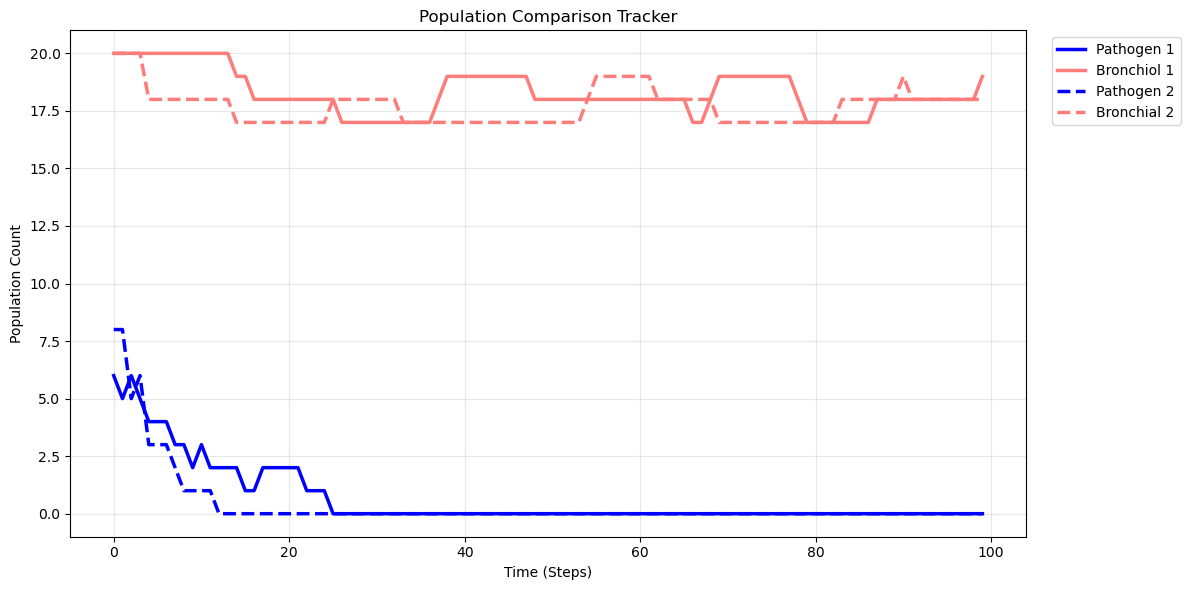

Summary of Data obtained
The higher pathogen count is found in Trial 2 with a maximum count of 8
More Bronchial death is found in Trial 1 with a minimum count of 17


In [453]:
#Note lmk if there are other values you wanna look at for either, cuz its not too hard to add 

#Once you have chosen the ideal parameters, you can run this cell to compare the two values!
#This will run a comparison of the concentrations of Pathogens and Bronchials in the each trial
# Set the step value
steps_to_run = 100

# Set the first parameters here!
MODEL_PARAMETERS = {
    "width": 20, # Grid width
    "height": 20, # Grid height
    #this is wher eu would put the parameter s(if we had any)
    "init_health_Bronchial": 100, # heaalth of bironchil
    "seed": 100, # Random seed for reproducibility
}

print(f"First simulation running")

first_simulator = ABMSimulator()
# New model instance separate from the one used in the SolaraViz
first_model = LungModel(
    simulator=first_simulator,
    **MODEL_PARAMETERS
)

# for _ in range(steps_to_run):
#     backup_model.step()
first_simulator.run_for(steps_to_run)
t1 = first_model.datacollector.get_model_vars_dataframe()


# Set the second parameters here!
MODEL_PARAMETERS = {
    "width": 20, # Grid width
    "height": 20, # Grid height
    #this is wher eu would put the parameter s(if we had any)
    "init_health_Bronchial": 50, # heaalth of bironchil
    "seed": 100, # Random seed for reproducibility
}

print(f"Second simulation running")

second_simulator = ABMSimulator()
# New model instance separate from the one used in the SolaraViz
second_model = LungModel(
    simulator=second_simulator,
    **MODEL_PARAMETERS
)

# for _ in range(steps_to_run):
#     backup_model.step()
second_simulator.run_for(steps_to_run)
t2 = second_model.datacollector.get_model_vars_dataframe()



plt.figure(figsize=(12, 6))

plt.plot(t1.index, t1["Pathogen"], color=AGENT_COLORS["Pathogen"], label="Pathogen 1", linewidth=2.5)
plt.plot(t1.index, t1["Bronchial"], color=AGENT_COLORS["Bronchial"], label="Bronchiol 1", linewidth=2.5)
plt.plot(t2.index, t2["Pathogen"], color=AGENT_COLORS["Pathogen"], label="Pathogen 2", linewidth=2.5, ls = '--')
plt.plot(t2.index, t2["Bronchial"], color=AGENT_COLORS["Bronchial"], label="Bronchial 2", linewidth=2.5, ls = '--')


# Formatting
plt.title("Population Comparison Tracker")
plt.xlabel("Time (Steps)")
plt.ylabel("Population Count")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1)) # Puts legend outside the plot
plt.grid(True, alpha=0.3)
plt.tight_layout()


# Display the plot
plt.show()

#note: if you would like to compare more values, it is possible to copy paste the code of the parameters and running said parameters in addition to adding the values into the plot!

#next is just a general comparison
Trials = ["Trial 1", "Trial 2"]
max_p_trials = [max(t1["Pathogen"]), max(t2["Pathogen"])]
min_b_trials = [min(t1["Bronchial"]), min(t2["Bronchial"])]

print("Summary of Data obtained")
print(f"The higher pathogen count is found in {Trials[max_p_trials.index(max(max_p_trials))]} with a maximum count of {(max(max_p_trials))}")
print(f"More Bronchial death is found in {Trials[min_b_trials.index(min(min_b_trials))]} with a minimum count of {(min(min_b_trials))}")


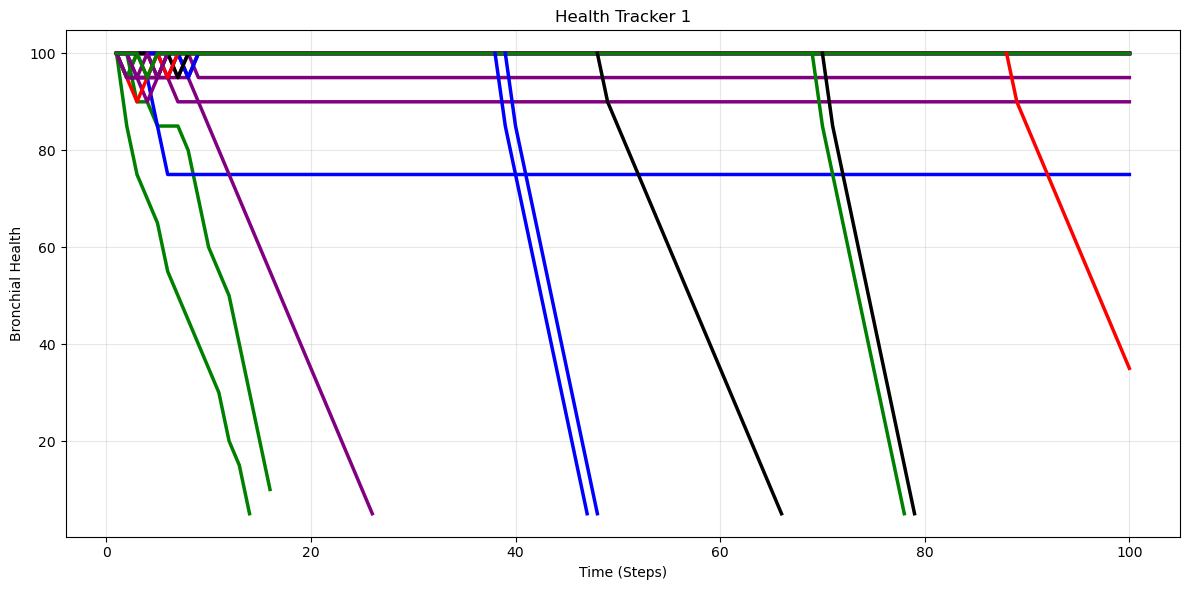

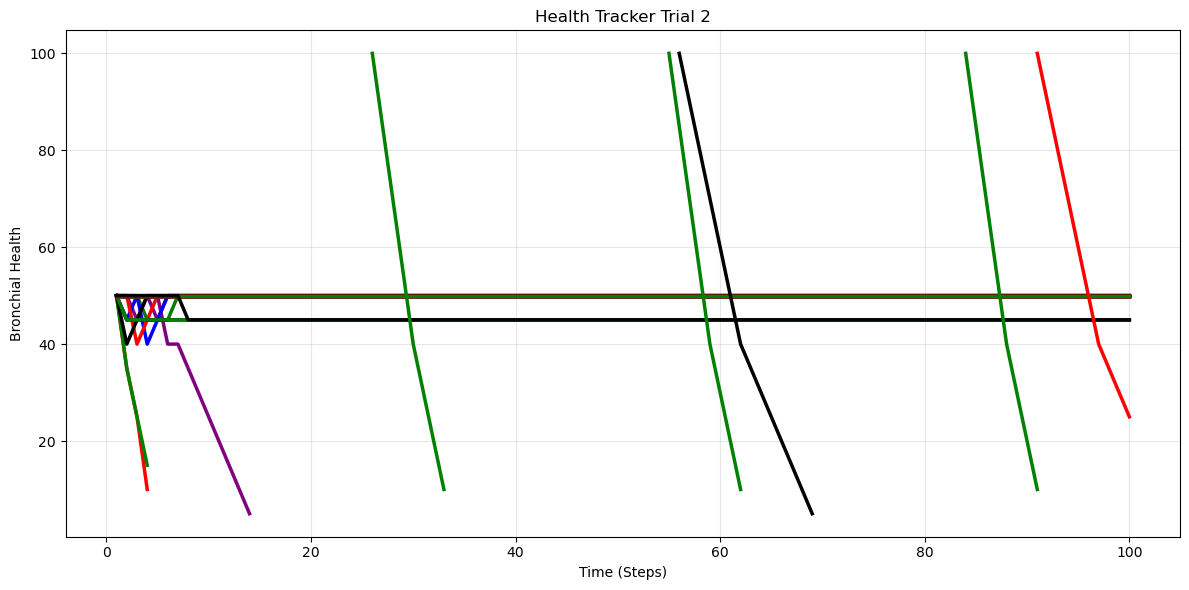

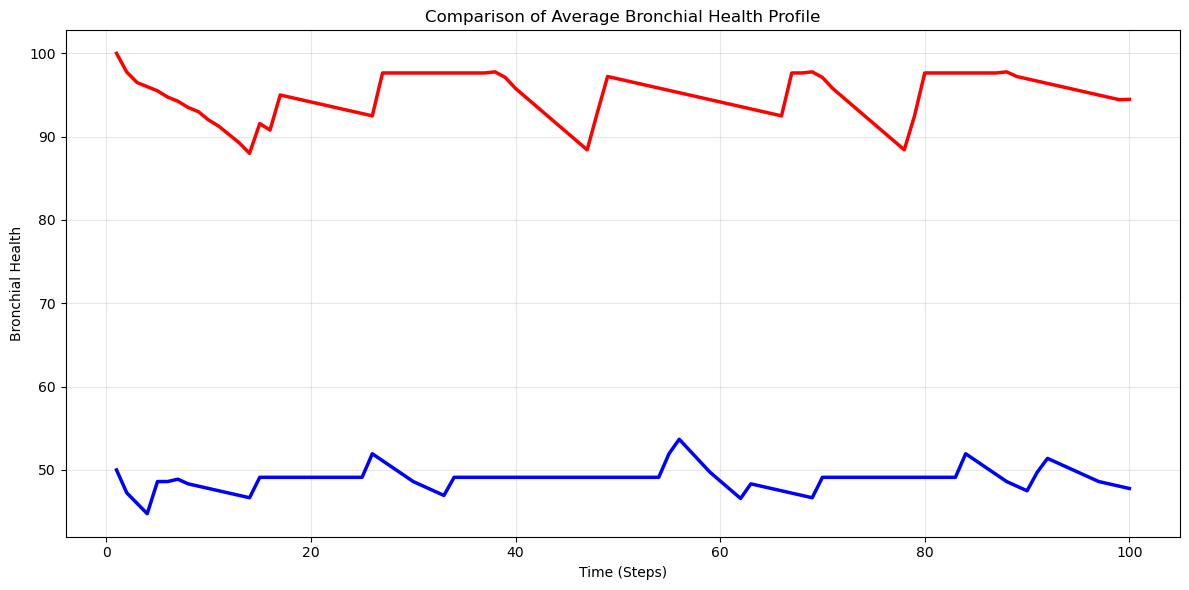

In [454]:
#using t1 and t2 from above, the data of the bronchial health is compiled
t1_agent = first_model.datacollector.get_agent_vars_dataframe()
t2_agent = second_model.datacollector.get_agent_vars_dataframe()

random_color = ["red","purple","blue","green", "black"] # lol this is the only thing i can think of to make it easier to read for now esp if we r working with so many types 

#First trial plot
plt.figure(figsize=(12, 6))
agents_1 = t1_agent.index.get_level_values("AgentID").unique()
for i in agents_1:
    health_b = t1_agent.xs(i, level="AgentID")
    plt.plot(health_b.index, health_b["Bronch_health"], color=random.choice(random_color), linewidth=2.5)

# Formatting
plt.title("Health Tracker 1")
plt.xlabel("Time (Steps)")
plt.ylabel("Bronchial Health")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()


#Second trial plot
plt.figure(figsize=(12, 6))
agents_2 = t2_agent.index.get_level_values("AgentID").unique()
for i in agents_2:
    health_b = t2_agent.xs(i, level="AgentID")
    plt.plot(health_b.index, health_b["Bronch_health"], color=random.choice(random_color), linewidth=2.5)

# Formatting
plt.title("Health Tracker Trial 2")
plt.xlabel("Time (Steps)")
plt.ylabel("Bronchial Health")
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Display the plot
plt.show()



#Average health profile over all bronchials in trials
plt.figure(figsize=(12, 6))

t1_health = t1_agent.groupby("Step")["Bronch_health"].mean()#index the step, average the health value
t2_health = t2_agent.groupby("Step")["Bronch_health"].mean()
plt.plot(t1_health.index, t1_health.values, color="red", linewidth=2.5, label ="Trial 1")
plt.plot(t2_health.index, t2_health.values, color="blue", linewidth=2.5, label = "Trial 2")


# Formatting
plt.title("Comparison of Average Bronchial Health Profile")
plt.xlabel("Time (Steps)")
plt.ylabel("Bronchial Health")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()



